Join the data from Part 1 with the data from Part 2 to create a new dataframe.

In [2]:
import sklearn
import sqlite3
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df1 = pd.read_csv('df_city_bikes.csv')
df1.rename(columns={'Name': 'Station Name'}, inplace = True)
df1
df = df.dropna()  # Handle missing values

,Unnamed: 0,Station ID,Station Name,Latitude,Longitude,Free Bikes
0,0,009ac5a5dfe1e13da61ea613ebd580dd,Alkmaar,52.637530,4.739850,143
1,1,00deaf43155f1d6c57891732c5434185,Amsterdam Noord,52.402374,4.931019,13
2,2,04672c55a75fa3cdef4533bd1277ec53,Hoogeveen,52.733090,6.473580,36
3,3,0725be1791baf25a0b247bf340560069,Zoetermeer Driemanspolder,52.049090,4.476630,19
4,4,07b969ad47b4381c47b2eaa0a50d3d30,Veenendaal Centrum,52.019787,5.549334,7
...,...,...,...,...,...,...
280,280,fd45aafc62edaa3a2759fc5ae6b83dea,Breda Centrum,51.595020,4.779437,128
281,281,fd61144b1ba7d7af027695e286da43eb,Zwolle Hanzeland,52.504990,6.091060,21
282,282,fdaf68bb8601c63dd8f165750f5d20dd,Beilen,52.854626,6.520572,12
283,283,fdceea2faa8e8b1c5abef210cebdb7d1,Horst Sevenum,51.427600,6.040800,11


In [4]:
df2 = pd.read_csv('yelp_data.csv')
df2
df = df.dropna()  # Handle missing values

,Unnamed: 0,Name,Distance,Rating,Station Name
0,0,De Binnenkomer,599.407294,4.7,Alkmaar
1,1,Vers Eten & Drinken,77.343360,4.5,Alkmaar
2,2,Daikichi,54.041312,4.0,Alkmaar
3,3,Burger King,38.753210,3.0,Alkmaar
4,4,Deli,1009.748379,4.8,Alkmaar
...,...,...,...,...,...
7495,7495,Ristobar Italica,1083.074462,2.4,Ravenstein
7496,7496,Le Bon,1008.708824,4.0,Ravenstein
7497,7497,De Bonte Bengel,574.722152,2.8,Ravenstein
7498,7498,Subway,861.824374,5.0,Ravenstein


In [5]:
df_outer = pd.merge(df2, df1, on='Station Name', how='outer')

In [6]:
df_outer

,Unnamed: 0_x,Name,Distance,Rating,Station Name,Unnamed: 0_y,Station ID,Latitude,Longitude,Free Bikes
0,7050.0,De Binnenkomer,599.407294,4.7,'s-Hertogenbosch Oost,141,87954eff506cced13e302e827ab3d15b,51.700878,5.319214,6
1,7051.0,Vers Eten & Drinken,77.343360,4.5,'s-Hertogenbosch Oost,141,87954eff506cced13e302e827ab3d15b,51.700878,5.319214,6
2,7052.0,Daikichi,54.041312,4.0,'s-Hertogenbosch Oost,141,87954eff506cced13e302e827ab3d15b,51.700878,5.319214,6
3,7053.0,Burger King,38.753210,3.0,'s-Hertogenbosch Oost,141,87954eff506cced13e302e827ab3d15b,51.700878,5.319214,6
4,7054.0,Deli,1009.748379,4.8,'s-Hertogenbosch Oost,141,87954eff506cced13e302e827ab3d15b,51.700878,5.319214,6
...,...,...,...,...,...,...,...,...,...,...
7630,2947.0,De Bonte Bengel,574.722152,2.8,Zwolle,58,3517201ff8e746d7000bd07d5290a5fb,52.505809,6.090895,359
7631,2948.0,Subway,861.824374,5.0,Zwolle,58,3517201ff8e746d7000bd07d5290a5fb,52.505809,6.090895,359
7632,2949.0,Cafe Bali,920.324472,3.7,Zwolle,58,3517201ff8e746d7000bd07d5290a5fb,52.505809,6.090895,359
7633,NaN,NaN,NaN,NaN,Zwolle Hanzeland,281,fd61144b1ba7d7af027695e286da43eb,52.504990,6.091060,21


Provide a visualization that you used as part of your EDA process. Explain the initial pattern or relationship you discoved through this visualization. 

In [8]:
df_outer_clean = df_outer.dropna(subset=["Name", "Distance", "Rating"])

Q1 = df_outer_clean[["Distance", "Rating"]].quantile(0.25)
Q3 = df_outer_clean[["Distance", "Rating"]].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_outer_clean = df_outer_clean[~((df_outer_clean[["Distance", "Rating"]] < lower_bound) | 
                                  (df_outer_clean[["Distance", "Rating"]] > upper_bound)).any(axis=1)]

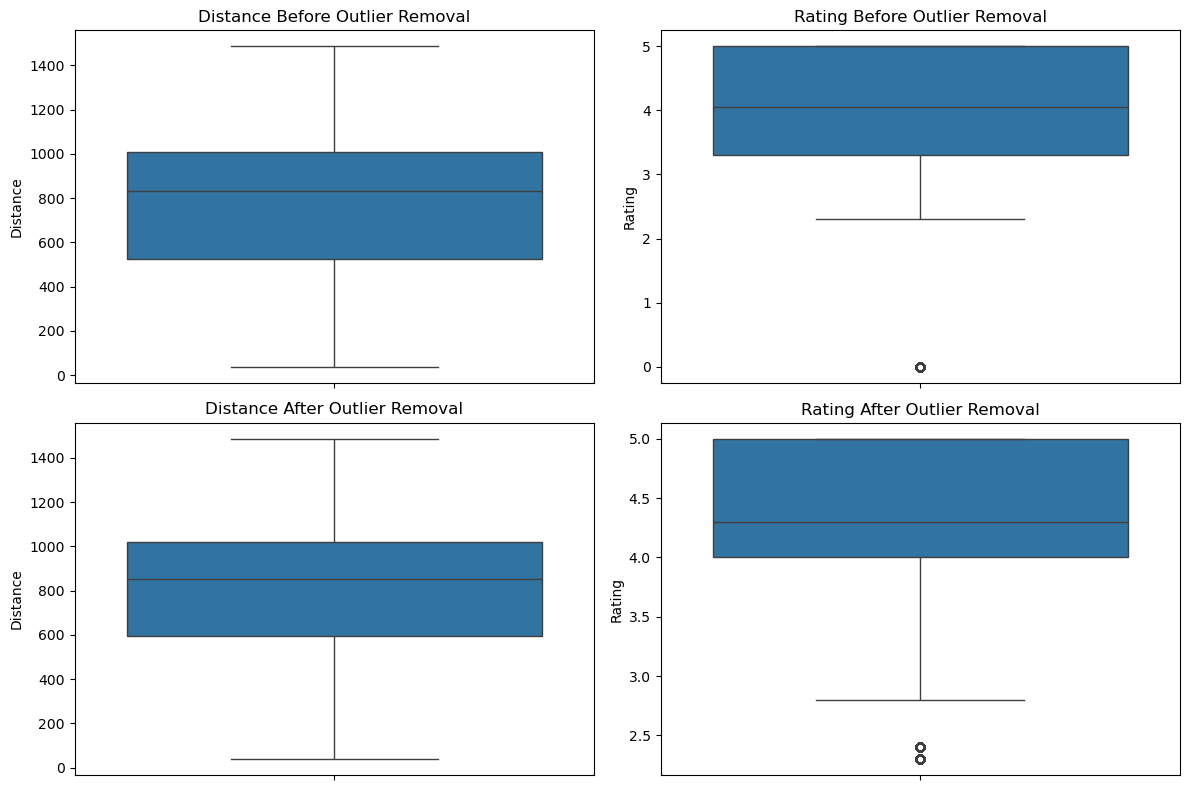

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(y=df_outer["Distance"], ax=axes[0, 0])
axes[0, 0].set_title("Distance Before Outlier Removal")

sns.boxplot(y=df_outer_clean["Distance"], ax=axes[1, 0])
axes[1, 0].set_title("Distance After Outlier Removal")

sns.boxplot(y=df_outer["Rating"], ax=axes[0, 1])
axes[0, 1].set_title("Rating Before Outlier Removal")

sns.boxplot(y=df_outer_clean["Rating"], ax=axes[1, 1])
axes[1, 1].set_title("Rating After Outlier Removal")

plt.tight_layout()
plt.show()

# Database

Put all your results in an SQLite3 database (remember, SQLite stores its databases as files in your local machine - make sure to create your database in your project's data/ directory!)

In [27]:
import sklearn
import matplotlib.pyplot
import requests
import pandas
import sqlite3
conn = sqlite3.connect("bike_stations.db")
df_outer_clean.to_sql("bike_data", conn, if_exists="replace", index=False)
conn.commit()
conn.close()

Look at the data before and after the join to validate your data.

In [30]:
conn = sqlite3.connect("bike_stations.db")
df = pd.read_sql("SELECT * FROM bike_data LIMIT 10;", conn)  # Adjust limit as needed
conn.close()
print(df)
df = df.dropna()  # Handle missing values

   Unnamed: 0_x                 Name     Distance  Rating  \
0        7050.0       De Binnenkomer   599.407294     4.7   
1        7051.0  Vers Eten & Drinken    77.343360     4.5   
2        7052.0             Daikichi    54.041312     4.0   
3        7053.0          Burger King    38.753210     3.0   
4        7054.0                 Deli  1009.748379     4.8   
5        7055.0           Anne & Max  1050.938905     4.8   
6        7056.0             De Buren  1060.793967     4.1   
7        7057.0            King Sing   212.273314     3.0   
8        7058.0                Aloha   852.744943     4.0   
9        7059.0  Stadsstrand de Kade   620.651334     5.0   

            Station Name  Unnamed: 0_y                        Station ID  \
0  's-Hertogenbosch Oost           141  87954eff506cced13e302e827ab3d15b   
1  's-Hertogenbosch Oost           141  87954eff506cced13e302e827ab3d15b   
2  's-Hertogenbosch Oost           141  87954eff506cced13e302e827ab3d15b   
3  's-Hertogenbosch Oost